<a href="https://colab.research.google.com/github/nolszewska135/Sztuczna-Inteligencja/blob/main/lab6_21193.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Instalacja bibliotek kompatybilnych z kodem ---
--- Rozpoczęcie nauki agenta (Q-Learning) ---
--- Nauka zakończona! ---

Ostateczna tablica Q-Table (wyznaczone optymalne ścieżki):
[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.66341019 0.69592214]
 [0.69833689 0.         0.52136293 0.63495432]
 [0.6519265  0.         0.30417233 0.3650068 ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.85736034 0.95       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


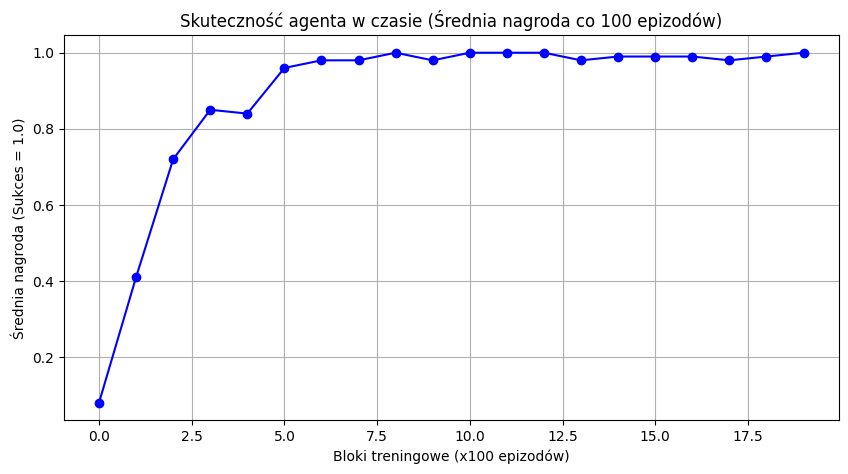

In [2]:
# ==============================================================================
# 1. INSTALACJA STABILNEJ WERSJI GYMNASIUM I BIBLIOTEK
# ==============================================================================
print("--- Instalacja bibliotek kompatybilnych z kodem ---")
# Instalujemy starszą, stabilną wersję 0.29.1, aby uniknąć błędów z ImportError
!pip install gymnasium==0.29.1 pygame numpy matplotlib > /dev/null 2>&1

import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

# ==============================================================================
# 2. INICJALIZACJA ŚRODOWISKA (FrozenLake-v1)
# ==============================================================================
# Środowisko FrozenLake-v1 (Zamarznięte Jezioro) zgodnie z instrukcją
env = gym.make('FrozenLake-v1', is_slippery=False)

# Rozmiar przestrzeni stanów (pól na planszy) i akcji (ruchów: góra, dół, lewo, prawo)
state_size = env.observation_space.n
action_size = env.action_space.n

# Inicjalizacja tablicy Q (Q-Table) samymi zerami
q_table = np.zeros((state_size, action_size))

# ==============================================================================
# 3. HIPERPARAMETRY ALGORYTMU Q-LEARNING
# ==============================================================================
total_episodes = 2000        # Liczba gier (epizodów)
learning_rate = 0.8          # Współczynnik uczenia (alfa)
discount_rate = 0.95         # Współczynnik dyskontowania (gamma)

# Parametry strategii eksploracji (Epsilon-Greedy)
epsilon = 1.0                # Początkowe prawdopodobieństwo losowego ruchu
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.005           # Szybkość zmniejszania eksploracji

# ==============================================================================
# 4. PROCES UCZENIA AGENTA
# ==============================================================================
rewards = [] # Lista do zapisywania nagród z każdego epizodu

print("--- Rozpoczęcie nauki agenta (Q-Learning) ---")
for episode in range(total_episodes):
    state, info = env.reset()
    done = False
    total_rewards = 0

    while not done:
        # Krok 1: Wybór akcji za pomocą strategii Epsilon-Greedy
        exp_exp_tradeoff = random.uniform(0, 1)

        if exp_exp_tradeoff > epsilon:
            # Eksploatacja: wybierz najlepszą znaną akcję z tabeli Q
            action = np.argmax(q_table[state, :])
        else:
            # Eksploracja: wykonaj losowy ruch
            action = env.action_space.sample()

        # Krok 2: Wykonanie akcji w środowisku
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Krok 3: Aktualizacja tablicy Q za pomocą równania Bellmana
        # Q(s,a) = Q(s,a) + lr * [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_rate * np.max(q_table[next_state, :]) - q_table[state, action]
        )

        total_rewards += reward
        state = next_state

    # Zmniejszanie wartości epsilon (mniej losowych ruchów w kolejnych grach)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards.append(total_rewards)

print("--- Nauka zakończona! ---")
print("\nOstateczna tablica Q-Table (wyznaczone optymalne ścieżki):")
print(q_table)

# ==============================================================================
# 5. WIZUALIZACJA WYNIKÓW (Skuteczność agenta)
# ==============================================================================
# Wykres pokazuje średnią nagrodę z bloków po 100 epizodów, aby widzieć progres
plt.figure(figsize=(10, 5))
chunks = np.array_split(rewards, total_episodes / 100)
mean_rewards = [np.mean(chunk) for chunk in chunks]

plt.plot(mean_rewards, marker='o', color='blue')
plt.title('Skuteczność agenta w czasie (Średnia nagroda co 100 epizodów)')
plt.xlabel('Bloki treningowe (x100 epizodów)')
plt.ylabel('Średnia nagroda (Sukces = 1.0)')
plt.grid(True)
plt.show()